In [23]:
import pandas as pd
df = pd.read_csv("/home/umoujahid/visualisation_project/data/Global-YouTube-Statistics_duplicates_dropped.csv")

In [24]:
df.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [25]:
df["created_year"].unique()

array([2006., 2012., 2013., 2015., 2010., 2016., 2018., 2014., 2007.,
       2020., 2008., 2005., 2011., 2009., 2017., 2021., 1970., 2019.,
         nan, 2022.])

In [26]:
df.dropna(subset=["created_year"],inplace = True)

In [27]:
df.isna().sum()

rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    120
Abbreviation                               120
channel_type                                27
video_views_rank                             0
country_rank                               114
channel_type_rank                           29
video_views_for_the_last_30_days            51
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               332
created_year                                 0
created_month                                0
created_date 

In [28]:
df["created_year"].unique()

array([2006., 2012., 2013., 2015., 2010., 2016., 2018., 2014., 2007.,
       2020., 2008., 2005., 2011., 2009., 2017., 2021., 1970., 2019.,
       2022.])

In [29]:
df["created_Full_date"] = pd.to_datetime(df["created_year"].astype(int).astype(str) + "-" + df["created_month"].astype(str) + "-" + df["created_date"].astype(int).astype(str) ,format="%Y-%b-%d" ,dayfirst=False).apply(lambda x: x.strftime("%Y"))

In [30]:
df["created_Full_date"]

0      2006
1      2006
2      2012
3      2006
4      2006
       ... 
990    2017
991    2018
992    2006
993    2012
994    2017
Name: created_Full_date, Length: 990, dtype: object

In [31]:
import matplotlib.pyplot as plt

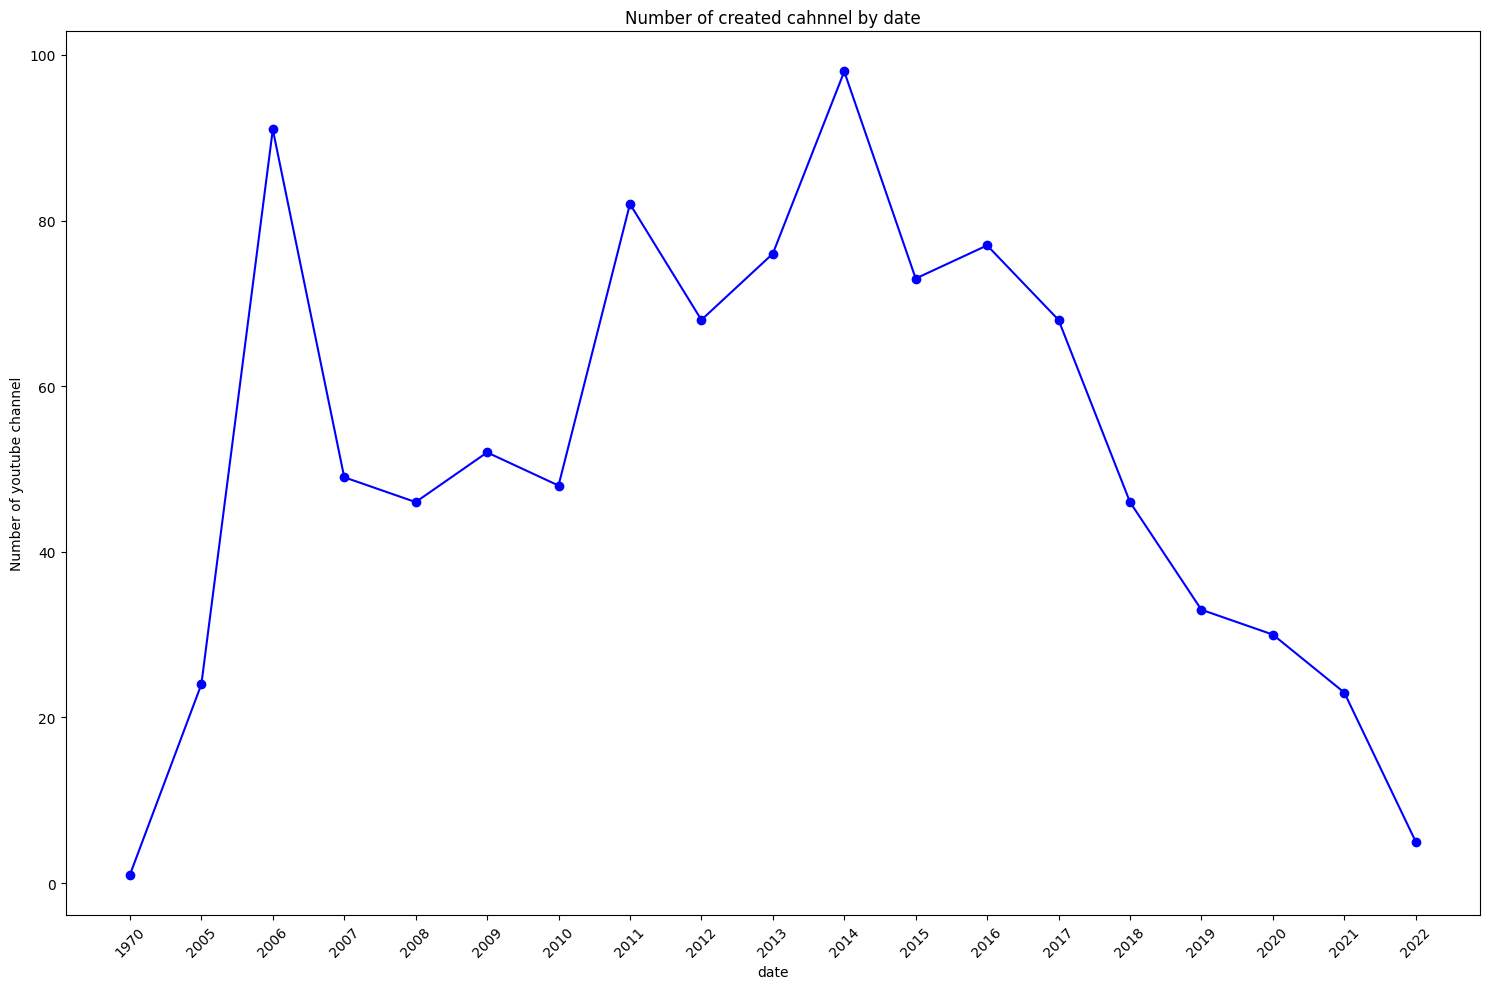

In [32]:
grouped = df.groupby("created_Full_date")["Youtuber"].count()

x = list(grouped.index)
y = list(grouped.values)
w = list(df.groupby("channel_type")["video_views_for_the_last_30_days"].sum()/1e9)

plt.figure(figsize=(15, 10))
plt.plot(x, y , marker='o', linestyle='-', color='b')
plt.title("Number of created cahnnel by date")
plt.xlabel("date")
plt.ylabel("Number of youtube channel")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
df.dropna(subset=["Latitude","Longitude","Country"] , inplace =True)


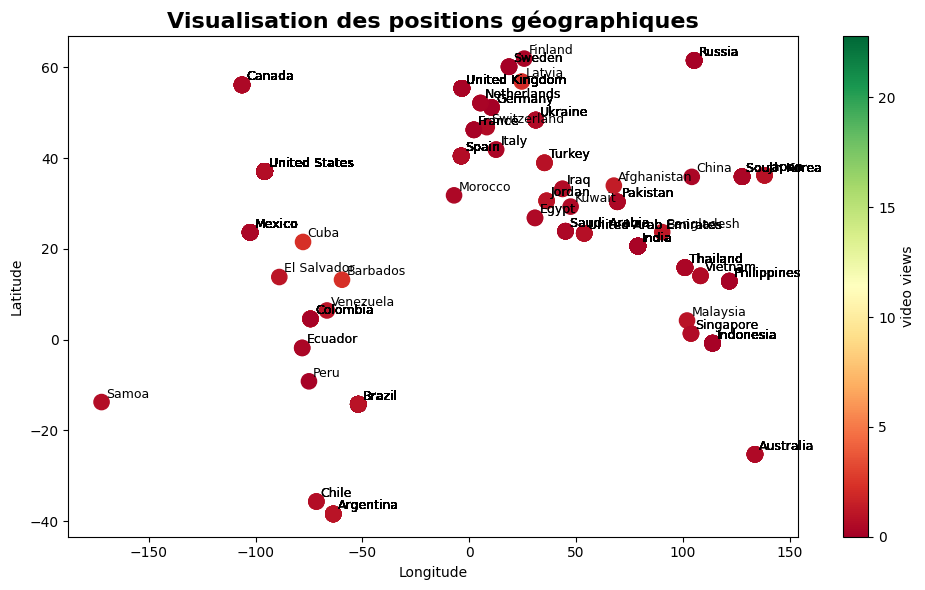

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

scatter = ax.scatter(
    df["Longitude"], df["Latitude"],
    c=df["video views"] / 1e10,
    s=120,
    cmap="RdYlGn"
)

for i in range(len(df)):
    ax.text(
        df.iloc[i]["Longitude"] + 2,
        df.iloc[i]["Latitude"] + 1,
        df.iloc[i]["Country"],
        fontsize=9
    )

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("video views")

ax.set_title("Visualisation des positions géographiques", fontsize=16, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

In [35]:
import geopandas as gpd
import geodatasets
from shapely.geometry import LineString

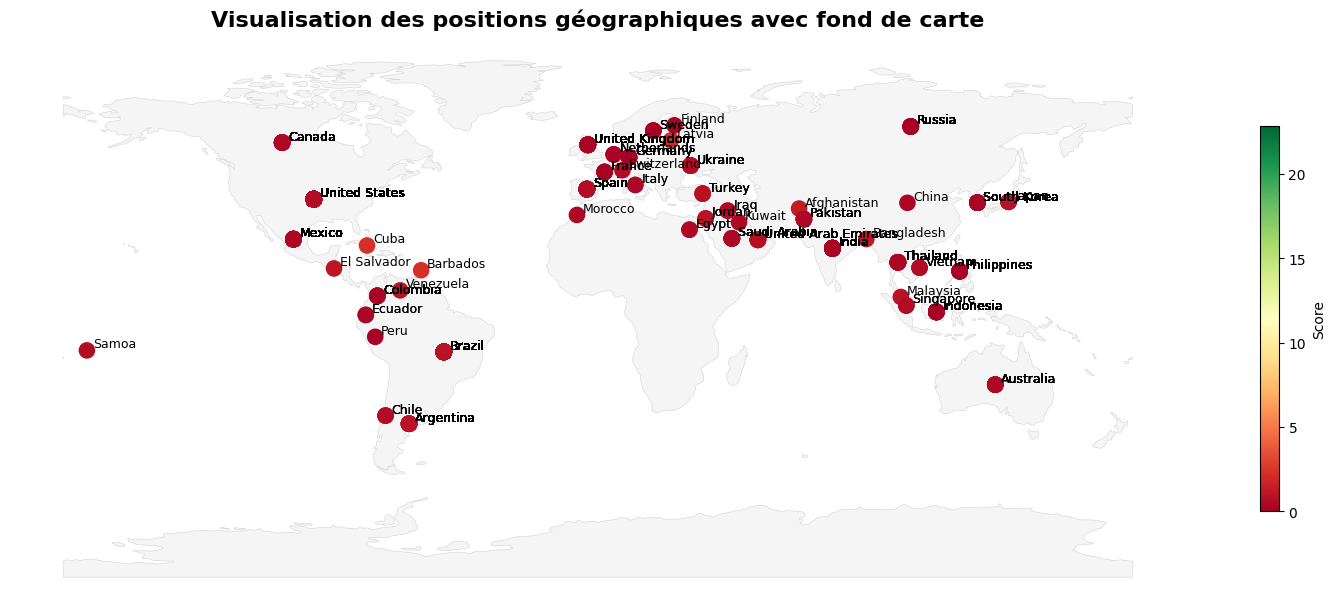

In [36]:
#Conversion en GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["Longitude"], df["Latitude"]),
    crs="EPSG:4326"
)
#Chargement du fond de carte
world = gpd.read_file(geodatasets.get_path("naturalearth.land"))

#Visualisation avec fond de carte
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

# fond de carte
world.plot(
    ax=ax,
    color="whitesmoke",
    edgecolor="lightgray",
    linewidth=0.4
)

# points
scatter = ax.scatter(
    gdf["Longitude"], gdf["Latitude"], c=gdf["video views"]/1e10,
    s=120,
    cmap="RdYlGn")

# noms des villes
for i in range(len(gdf)):
    ax.text(
        gdf.iloc[i] ["Longitude"] + 2,
        gdf.iloc[i] ["Latitude"] + 1,
        gdf.iloc[i] ["Country"],
        fontsize=9
    )

# barre de couleur
cbar = plt.colorbar(scatter, ax=ax, shrink=0.5)
cbar.set_label("Score")

ax.set_title("Visualisation des positions géographiques avec fond de carte", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()
